In [1]:
import pandas as pd

## **Cargamos datos "procesados"**

In [2]:
df_jan = pd.read_parquet("data/processed/jan.parquet")
df_feb = pd.read_parquet("data/processed/feb.parquet")


## **EDA**

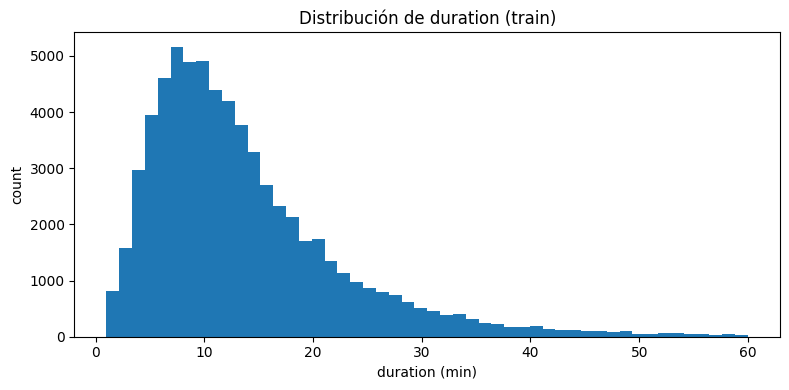

ehail_fee                1.000000
trip_type                0.065129
store_and_fwd_flag       0.065053
congestion_surcharge     0.065053
passenger_count          0.065053
payment_type             0.065053
RatecodeID               0.065053
tolls_amount             0.000000
total_amount             0.000000
improvement_surcharge    0.000000
dtype: float64

In [3]:
import matplotlib.pyplot as plt

# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_jan["duration"], bins=50)
ax.set_title("Distribución de duration (train)")
ax.set_xlabel("duration (min)")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

# Missingness simple
missing = df_jan.isna().mean().sort_values(ascending=False).head(10)
missing

## **Definir columnas a modelar**

In [4]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ["trip_distance"]

## Definir set de train y test

In [5]:
df_train = df_jan
df_val = df_feb

## **Preprocesar**

In [6]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df_train = df_train.copy()
df_val   = df_val.copy()
df_train["categorical_dict"] = df_train[categorical].to_dict(orient="records")
df_val["categorical_dict"]   = df_val[categorical].to_dict(orient="records")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", DictVectorizer(), "categorical_dict"),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numerical),
    ]
)

X_train = preprocessor.fit_transform(df_train)
y_train = df_train["duration"].values
X_val   = preprocessor.transform(df_val)
y_val   = df_val["duration"].values









## **Entrenar**

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)


## **Metricas de modelado**

In [8]:
from sklearn.metrics import root_mean_squared_error


rmse = root_mean_squared_error(y_val, y_pred)

In [9]:
rmse

5.137713717868471

## **Next Steps**

1. ¿Dónde guardo los hiperparámetros de cada experimento?
2. ¿Dónde guardo las métricas (RMSE/MAE/R2) de forma comparable?
3. ¿Cómo guardo el modelo entrenado y lo recupero después?
4. ¿Cómo guardo plots (residuals, feature importance) de cada experimento?

En el siguiente notebook vamos a resolver esto con **MLflow experiment tracking**.